In [1]:
import pandas as pd
import numpy as np
from scipy import stats

# --------------------------------------------------
# Load data
# --------------------------------------------------
df = pd.read_csv("../data/ACAI-US79-scored.csv")

# --------------------------------------------------
# Subgroup preprocessing (no dummies)
# --------------------------------------------------

# ---- Parse Size string (e.g., "~80k students") to numeric ----
def parse_size(size_str):
    if pd.isna(size_str):
        return np.nan

    s = size_str.lower()
    s = s.replace("students", "").replace("~", "").strip()

    if "k" in s:
        return float(s.replace("k", "").strip()) * 1000

    return float(s.replace(",", ""))

df["size_numeric"] = df["Size"].apply(parse_size)

# ---- Bucket size (tertiles: small / medium / large) ----
df["size_bucket"] = pd.qcut(
    df["size_numeric"],
    q=3,
    labels=["small", "medium", "large"]
)

# ---- Sanity checks (recommended) ----
print("Type counts:")
print(df["Type"].value_counts(), "\n")

print("Research Activity counts:")
print(df["Research Activity"].value_counts(), "\n")

print("Regional Coverage counts:")
print(df["Regional Coverage"].value_counts(), "\n")

print("Size bucket counts:")
print(df["size_bucket"].value_counts())


# --------------------------------------------------
# Helper: Cohen's d
# --------------------------------------------------
def cohens_d_safe(x, y):
    if len(x) < 2 or len(y) < 2:
        return np.nan

    nx, ny = len(x), len(y)
    vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)

    pooled_sd = np.sqrt(((nx - 1)*vx + (ny - 1)*vy) / (nx + ny - 2))
    return (np.mean(x) - np.mean(y)) / pooled_sd

# --------------------------------------------------
# Helper: CI for mean difference
# --------------------------------------------------
from scipy import stats
import numpy as np

def mean_diff_ci_safe(x, y, alpha=0.05):
    x = np.asarray(x)
    y = np.asarray(y)

    if len(x) < 2 or len(y) < 2:
        return np.nan, np.nan, np.nan

    res = stats.ttest_ind(x, y, equal_var=False)

    mean_diff = x.mean() - y.mean()
    se = abs(mean_diff / res.statistic)
    tcrit = stats.t.ppf(1 - alpha/2, res.df)

    return (
        mean_diff,
        mean_diff - tcrit * se,
        mean_diff + tcrit * se
    )

# --------------------------------------------------
# Exploratory two-group comparison
# --------------------------------------------------
def exploratory_two_group(
    df,
    group_col,
    group_a,
    group_b,
    value_col
):
    x = df[df[group_col] == group_a][value_col].dropna()
    y = df[df[group_col] == group_b][value_col].dropna()

    mean_x = x.mean() if len(x) > 0 else np.nan
    mean_y = y.mean() if len(y) > 0 else np.nan

    d = cohens_d_safe(x, y)
    diff, ci_low, ci_high = mean_diff_ci_safe(x, y)

    if len(x) >= 2 and len(y) >= 2:
        tstat, pval = stats.ttest_ind(x, y, equal_var=True)
    else:
        tstat, pval = np.nan, np.nan

    return {
        "grouping_variable": group_col,
        "group_A": group_a,
        "group_B": group_b,
        "n_A": len(x),
        "n_B": len(y),
        "mean_A": mean_x,
        "mean_B": mean_y,
        "mean_diff": diff,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "cohens_d": d,
        "t_stat": tstat,
        "p_value": pval,
    }


# --------------------------------------------------
# Exploratory subgroup analysis (all subgroups × all schemes)
# --------------------------------------------------

from itertools import combinations

# --------------------------------------------------
# Subgroup definitions (explicit, auditable)
# --------------------------------------------------
subgroups = {
    "Type": ["Public Research-Oriented", "Private Research-Oriented", "Teaching-Oriented/Liberal Arts"],
    "Regional Coverage": ["South", "West", "Midwest", "Northeast"],
    "size_bucket": ["small", "medium", "large"],
    "Research Activity": ["R1", "R2"],
}

schemes = [
    "ACAI_indicators",
    "ACAI_equal",
    "ACAI_policy_heavy",
    "ACAI_teaching_heavy",
]

rows = []

# --------------------------------------------------
# Loop over subgroup variables
# --------------------------------------------------
for subgroup_col, levels in subgroups.items():

    # Only keep levels that actually exist in the data
    present_levels = [
        lvl for lvl in levels
        if lvl in df[subgroup_col].dropna().unique()
    ]

    # All pairwise contrasts within this subgroup
    for group_a, group_b in combinations(present_levels, 2):

        for scheme in schemes:
            res = exploratory_two_group(
                df=df,
                group_col=subgroup_col,
                group_a=group_a,
                group_b=group_b,
                value_col=scheme
            )

            res.update({
                "subgroup": subgroup_col,
                "group_A": group_a,
                "group_B": group_b,
                "scheme": scheme,
            })

            rows.append(res)

# --------------------------------------------------
# Results dataframe
# --------------------------------------------------
df_subgroup_results = pd.DataFrame(rows)

# Round all numeric columns to 2 decimal places
numeric_cols = df_subgroup_results.select_dtypes(include="number").columns
df_subgroup_results[numeric_cols] = df_subgroup_results[numeric_cols].round(2)

display(df_subgroup_results)

Type counts:
Type
Public Research-Oriented          33
Private Research-Oriented         30
Teaching-Oriented/Liberal Arts    16
Name: count, dtype: int64 

Research Activity counts:
Research Activity
R1    33
R2    30
-     16
Name: count, dtype: int64 

Regional Coverage counts:
Regional Coverage
South        21
Midwest      20
Northeast    20
West         18
Name: count, dtype: int64 

Size bucket counts:
size_bucket
small     27
large     27
medium    25
Name: count, dtype: int64


,grouping_variable,group_A,group_B,n_A,n_B,mean_A,mean_B,mean_diff,ci_low,ci_high,cohens_d,t_stat,p_value,subgroup,scheme
0,Type,Public Research-Oriented,Private Research-Oriented,33,30,61.85,57.42,4.42,-2.06,10.90,0.35,1.37,0.17,Type,ACAI_indicators
1,Type,Public Research-Oriented,Private Research-Oriented,33,30,61.11,55.90,5.21,-1.33,11.75,0.41,1.61,0.11,Type,ACAI_equal
2,Type,Public Research-Oriented,Private Research-Oriented,33,30,55.68,50.60,5.08,-1.72,11.88,0.38,1.50,0.14,Type,ACAI_policy_heavy
3,Type,Public Research-Oriented,Private Research-Oriented,33,30,63.99,59.50,4.49,-2.00,10.98,0.35,1.39,0.17,Type,ACAI_teaching_heavy
4,Type,Public Research-Oriented,Teaching-Oriented/Liberal Arts,33,16,61.85,53.12,8.72,2.32,15.12,0.77,2.53,0.01,Type,ACAI_indicators
5,Type,Public Research-Oriented,Teaching-Oriented/Liberal Arts,33,16,61.11,52.99,8.12,1.89,14.34,0.73,2.40,0.02,Type,ACAI_equal
6,Type,Public Research-Oriented,Teaching-Oriented/Liberal Arts,33,16,55.68,46.61,9.07,2.37,15.76,0.77,2.52,0.02,Type,ACAI_policy_heavy
7,Type,Public Research-Oriented,Teaching-Oriented/Liberal Arts,33,16,63.99,55.31,8.68,2.40,14.96,0.78,2.55,0.01,Type,ACAI_teaching_heavy
8,Type,Private Research-Oriented,Teaching-Oriented/Liberal Arts,30,16,57.42,53.12,4.30,-2.59,11.19,0.35,1.13,0.26,Type,ACAI_indicators
9,Type,Private Research-Oriented,Teaching-Oriented/Liberal Arts,30,16,55.90,52.99,2.91,-3.92,9.73,0.24,0.76,0.45,Type,ACAI_equal


In [2]:
pd.set_option("display.max_rows", None)

# --------------------------------------------------
# Helper: conditional exploratory comparison
# --------------------------------------------------
def exploratory_two_group_conditional(
    df,
    condition_col,
    condition_value,
    group_col,
    group_a,
    group_b,
    value_col
):
    df_sub = df[df[condition_col] == condition_value]

    return exploratory_two_group(
        df=df_sub,
        group_col=group_col,
        group_a=group_a,
        group_b=group_b,
        value_col=value_col
    )

# --------------------------------------------------
# Exhaustive two-way subgroup analysis
# --------------------------------------------------
for (cond_col, cond_levels), (grp_col, grp_levels) in combinations(subgroups.items(), 2):

    # Only consider levels that actually exist
    cond_levels_present = [
        lvl for lvl in cond_levels if lvl in df[cond_col].unique()
    ]
    grp_levels_present = [
        lvl for lvl in grp_levels if lvl in df[grp_col].unique()
    ]

    for cond_val in cond_levels_present:

        # All pairwise contrasts within the grouped variable
        for group_a, group_b in combinations(grp_levels_present, 2):

            for scheme in schemes:
                res = exploratory_two_group_conditional(
                    df=df,
                    condition_col=cond_col,
                    condition_value=cond_val,
                    group_col=grp_col,
                    group_a=group_a,
                    group_b=group_b,
                    value_col=scheme
                )

                res.update({
                    "subgroup_A": cond_col,
                    "condition_A": cond_val,
                    "subgroup_B": grp_col,
                    "group_B1": group_a,
                    "group_B2": group_b,
                    "scheme": scheme,
                })

                rows.append(res)

# --------------------------------------------------
# Results dataframe
# --------------------------------------------------
df_subgroup_results = pd.DataFrame(rows)

# Round numeric columns
numeric_cols = df_subgroup_results.select_dtypes(include="number").columns
df_subgroup_results[numeric_cols] = df_subgroup_results[numeric_cols].round(2)

# --------------------------------------------------
# Reorder columns for readability
# --------------------------------------------------
preferred_order = [
    # Subgroup structure
    "subgroup_A",
    "condition_A",
    "subgroup_B",
    "group_B1",
    "group_B2",
    "scheme",

    # Sample sizes
    "n_A",
    "n_B",

    # Group means
    "mean_A",
    "mean_B",

    # Effect estimates
    "mean_diff",
    "ci_low",
    "ci_high",
    "cohens_d",

    # Test stats (exploratory / secondary)
    "t_stat",
    "p_value",
]

# Keep only columns that actually exist (safety)
ordered_cols = [c for c in preferred_order if c in df_subgroup_results.columns]

# Append any remaining columns at the end
remaining_cols = [c for c in df_subgroup_results.columns if c not in ordered_cols]

df_subgroup_results = df_subgroup_results[ordered_cols + remaining_cols]


display(df_subgroup_results)

,subgroup_A,condition_A,subgroup_B,group_B1,group_B2,scheme,n_A,n_B,mean_A,mean_B,mean_diff,ci_low,ci_high,cohens_d,t_stat,p_value,grouping_variable,group_A,group_B,subgroup
0,NaN,NaN,NaN,NaN,NaN,ACAI_indicators,33,30,61.85,57.42,4.42,-2.06,10.90,0.35,1.37,0.17,Type,Public Research-Oriented,Private Research-Oriented,Type
1,NaN,NaN,NaN,NaN,NaN,ACAI_equal,33,30,61.11,55.90,5.21,-1.33,11.75,0.41,1.61,0.11,Type,Public Research-Oriented,Private Research-Oriented,Type
2,NaN,NaN,NaN,NaN,NaN,ACAI_policy_heavy,33,30,55.68,50.60,5.08,-1.72,11.88,0.38,1.50,0.14,Type,Public Research-Oriented,Private Research-Oriented,Type
3,NaN,NaN,NaN,NaN,NaN,ACAI_teaching_heavy,33,30,63.99,59.50,4.49,-2.00,10.98,0.35,1.39,0.17,Type,Public Research-Oriented,Private Research-Oriented,Type
4,NaN,NaN,NaN,NaN,NaN,ACAI_indicators,33,16,61.85,53.12,8.72,2.32,15.12,0.77,2.53,0.01,Type,Public Research-Oriented,Teaching-Oriented/Liberal Arts,Type
5,NaN,NaN,NaN,NaN,NaN,ACAI_equal,33,16,61.11,52.99,8.12,1.89,14.34,0.73,2.40,0.02,Type,Public Research-Oriented,Teaching-Oriented/Liberal Arts,Type
6,NaN,NaN,NaN,NaN,NaN,ACAI_policy_heavy,33,16,55.68,46.61,9.07,2.37,15.76,0.77,2.52,0.02,Type,Public Research-Oriented,Teaching-Oriented/Liberal Arts,Type
7,NaN,NaN,NaN,NaN,NaN,ACAI_teaching_heavy,33,16,63.99,55.31,8.68,2.40,14.96,0.78,2.55,0.01,Type,Public Research-Oriented,Teaching-Oriented/Liberal Arts,Type
8,NaN,NaN,NaN,NaN,NaN,ACAI_indicators,30,16,57.42,53.12,4.30,-2.59,11.19,0.35,1.13,0.26,Type,Private Research-Oriented,Teaching-Oriented/Liberal Arts,Type
9,NaN,NaN,NaN,NaN,NaN,ACAI_equal,30,16,55.90,52.99,2.91,-3.92,9.73,0.24,0.76,0.45,Type,Private Research-Oriented,Teaching-Oriented/Liberal Arts,Type


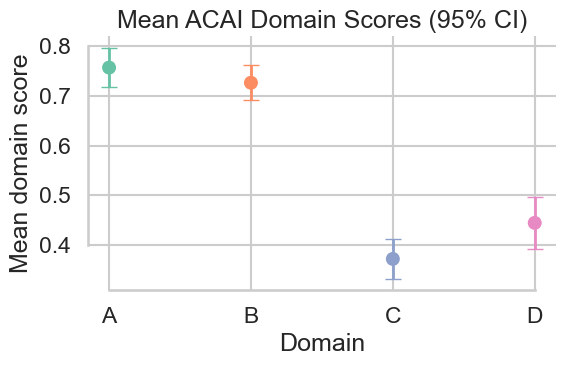

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# --------------------------------------------------
# Tidy domain summary
# --------------------------------------------------
domains = ["A", "B", "C", "D"]

rows = []
for d in domains:
    vals = df[f"mean_{d}"].dropna()
    n = len(vals)
    mean = vals.mean()
    se = vals.std(ddof=1) / np.sqrt(n)
    tcrit = stats.t.ppf(0.975, n - 1)

    rows.append({
        "domain": d,
        "mean": mean,
        "ci_low": mean - tcrit * se,
        "ci_high": mean + tcrit * se,
    })

df_plot = pd.DataFrame(rows)

sns.set_theme(
    style="whitegrid",
    context="talk",
    font_scale=1.0
)

palette = sns.color_palette("Set2", n_colors=4)

plt.figure(figsize=(6, 4))
ax = sns.scatterplot(
    data=df_plot,
    x="domain",
    y="mean",
    hue="domain",
    palette=palette,
    s=120,
    legend=False
)

for i, row in df_plot.iterrows():
    ax.errorbar(
        x=i,
        y=row["mean"],
        yerr=[
            [row["mean"] - row["ci_low"]],
            [row["ci_high"] - row["mean"]],
        ],
        fmt="none",
        capsize=6,
        color=palette[i],
        linewidth=2
    )

ax.set_ylabel("Mean domain score")
ax.set_xlabel("Domain")
ax.set_title("Mean ACAI Domain Scores (95% CI)")

sns.despine(trim=True)
plt.tight_layout()
plt.show()



/var/folders/n2/yfmlyvts65xd64jgl_j_5jk80000gn/T/ipykernel_55466/3614260293.py:179: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


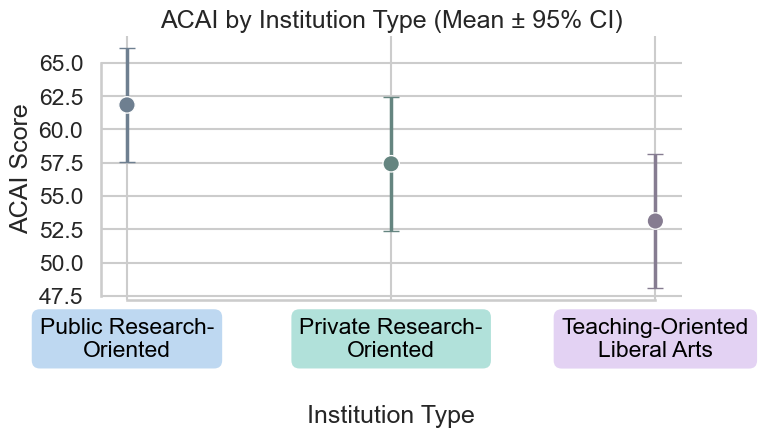

/var/folders/n2/yfmlyvts65xd64jgl_j_5jk80000gn/T/ipykernel_55466/3614260293.py:179: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


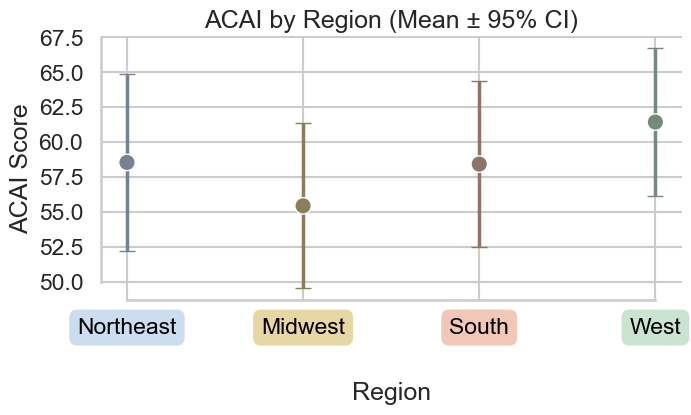

/var/folders/n2/yfmlyvts65xd64jgl_j_5jk80000gn/T/ipykernel_55466/3614260293.py:179: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


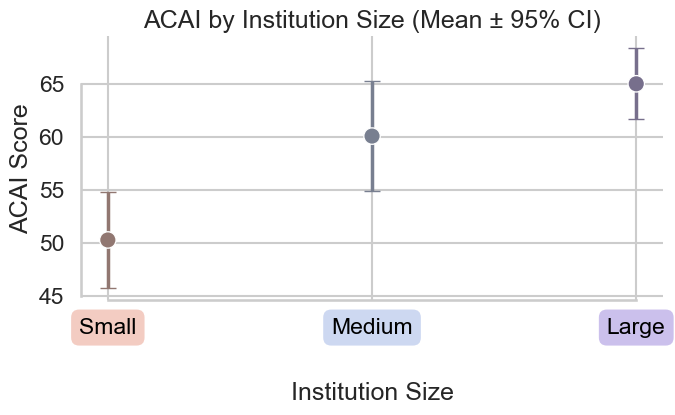

/var/folders/n2/yfmlyvts65xd64jgl_j_5jk80000gn/T/ipykernel_55466/3614260293.py:179: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


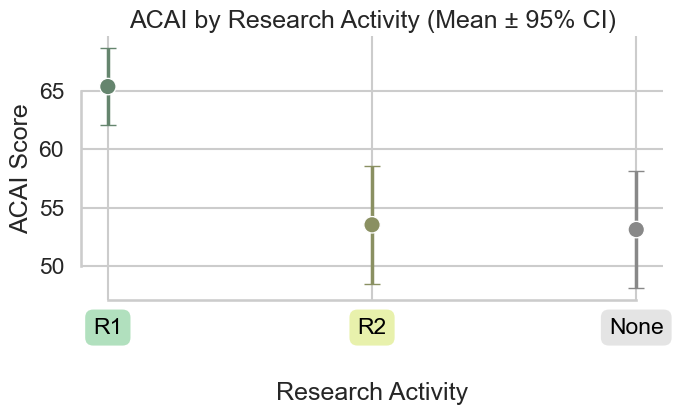

In [4]:
import matplotlib.colors as mcolors
import numpy as np

def darken_color(hex_color, factor=0.03):
    """
    Darken a hex color by multiplying RGB channels.
    factor < 1 → darker
    """
    rgb = np.array(mcolors.to_rgb(hex_color))
    return mcolors.to_hex(rgb * factor)

def text_color_for_bg(hex_color):
    """
    Choose black/white text based on luminance.
    """
    r, g, b = mcolors.to_rgb(hex_color)
    luminance = 0.299*r + 0.587*g + 0.114*b
    return "black" if luminance > 0.6 else "white"

ORDER_MAP = {
    "size_bucket": ["small", "medium", "large"],
    "Research Activity": ["R1", "R2", "-"],
    "Regional Coverage": ["Northeast", "Midwest", "South", "West"],
    "Type": [
        "Public Research-Oriented",
        "Private Research-Oriented",
        "Teaching-Oriented/Liberal Arts",
    ],
}

COLOR_MAP = {
    "Type": {
        "Public Research-Oriented": "#B7D4F0",
        "Private Research-Oriented": "#A9DED6",
        "Teaching-Oriented/Liberal Arts": "#E0CEF2"
    },
    "Research Activity": {
        "R1": "#A9DDB7",
        "R2": "#E6F0A3",
        "-": "#E2E2E2"
    },
    "Regional Coverage": {
        "South": "#F0C1B1",
        "Midwest": "#E6D39B",
        "Northeast": "#C7D9F0",
        "West": "#C6E2CE"
    },
    "size_bucket": {
        "small": "#F2C7BC",
        "medium": "#C8D4F0",
        "large": "#C6B9EA"
    }
}

LABEL_MAP = {
    "Type": {
        "Teaching-Oriented/Liberal Arts": "Teaching-Oriented\nLiberal Arts",
        "Private Research-Oriented": "Private Research-\nOriented",
        "Public Research-Oriented": "Public Research-\nOriented",
    },
    "Regional Coverage": {
        "Midwest": "Midwest",
        "South": "South",
        "Northeast": "Northeast",
        "West": "West",
    },
    "Research Activity": {
        "R1": "R1",
        "R2": "R2",
        "-": "None",
    },
    "size_bucket": {
        "small": "Small",
        "medium": "Medium",
        "large": "Large",
    }
}

SUBGROUP_DISPLAY_NAMES = {
    "Type": "Institution Type",
    "Regional Coverage": "Region",
    "Research Activity": "Research Activity",
    "size_bucket": "Institution Size",
}


from scipy import stats
import pandas as pd

def summarize_mean_ci(df, group_col, value_col, alpha=0.05):
    rows = []

    order = ORDER_MAP.get(group_col)
    levels = order if order is not None else df[group_col].dropna().unique()

    for level in levels:
        vals = df[df[group_col] == level][value_col].dropna()
        n = len(vals)
        if n < 2:
            continue

        mean = vals.mean()
        se = vals.std(ddof=1) / np.sqrt(n)
        tcrit = stats.t.ppf(1 - alpha/2, n - 1)

        rows.append({
            "subgroup": group_col,
            "level": level,
            "n": n,
            "mean": mean,
            "ci_low": mean - tcrit * se,
            "ci_high": mean + tcrit * se,
        })

    return pd.DataFrame(rows)

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")

def plot_subgroup_means(df_plot, subgroup):
    d = df_plot[df_plot["subgroup"] == subgroup].copy()
    # d = d.sort_values("mean")

    order = ORDER_MAP.get(subgroup)
    if order is not None:
        d["level"] = pd.Categorical(
            d["level"],
            categories=order,
            ordered=True
        )
        d = d.sort_values("level")


    base_palette = COLOR_MAP[subgroup]
    dark_palette = {
        k: darken_color(v, factor=0.6)
        for k, v in base_palette.items()
    }

    fig, ax = plt.subplots(figsize=(7.5, 4.8))

    sns.scatterplot(
        data=d,
        x="level",
        y="mean",
        hue="level",
        palette=dark_palette,
        s=140,
        legend=False,
        ax=ax,
        zorder=3
    )

    # CI bars
    for _, row in d.iterrows():
        ax.errorbar(
            x=row["level"],
            y=row["mean"],
            yerr=[
                [row["mean"] - row["ci_low"]],
                [row["ci_high"] - row["mean"]],
            ],
            fmt="none",
            capsize=6,
            linewidth=2.5,
            color=dark_palette[row["level"]],
            zorder=2
        )

    # ---- Multiline, centered tick labels ----
    raw_labels = [t.get_text() for t in ax.get_xticklabels()]
    pretty_labels = [
        LABEL_MAP.get(subgroup, {}).get(lbl, lbl)
        for lbl in raw_labels
    ]

    ax.set_xticklabels(
        pretty_labels,
        rotation=0,
        ha="center",
        multialignment="center"
    )

    for tick, raw_label in zip(ax.get_xticklabels(), raw_labels):
        bg = base_palette.get(raw_label, "#FFFFFF")

        tick.set_bbox(dict(
            facecolor=bg,
            edgecolor="none",
            boxstyle="round,pad=0.35",
            alpha=0.9
        ))
        tick.set_color(text_color_for_bg(bg))

    # ---- Titles & labels ----
    ax.set_title("ACAI by " + SUBGROUP_DISPLAY_NAMES[subgroup] + " (Mean ± 95% CI)")
    ax.set_xlabel(SUBGROUP_DISPLAY_NAMES[subgroup], labelpad=32)
    ax.set_ylabel("ACAI Score")

    sns.despine(trim=True)

    # Space for multiline ticks
    fig.subplots_adjust(bottom=0.33)

    plt.show()


plot_rows = []

for subgroup_col in subgroups.keys():
    plot_rows.append(
        summarize_mean_ci(
            df=df,
            group_col=subgroup_col,
            value_col="ACAI_indicators"
        )
    )

df_plot_all = pd.concat(plot_rows, ignore_index=True)

for subgroup_col in subgroups.keys():
    plot_subgroup_means(
        df_plot=df_plot_all,
        subgroup=subgroup_col
    )
    

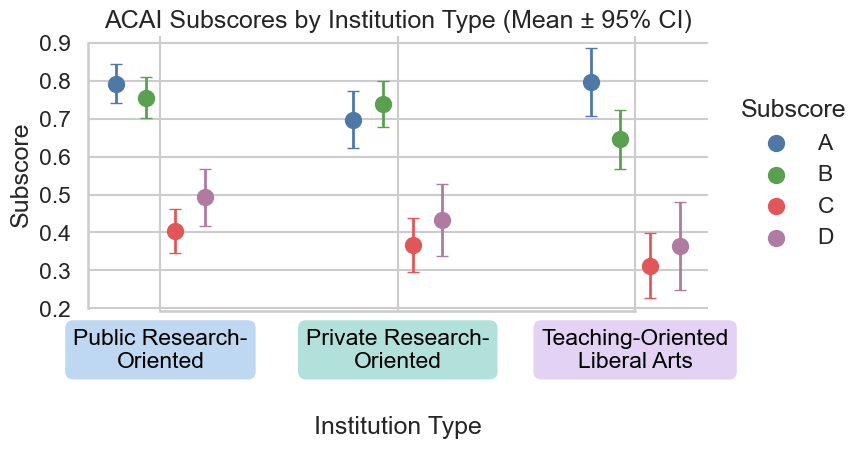

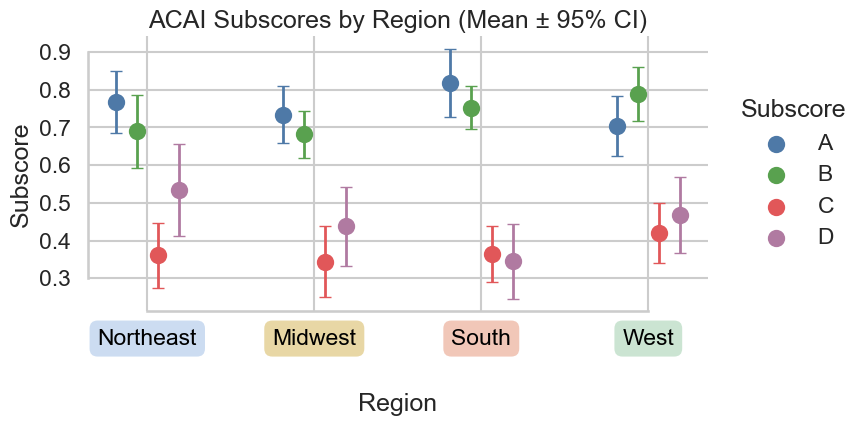

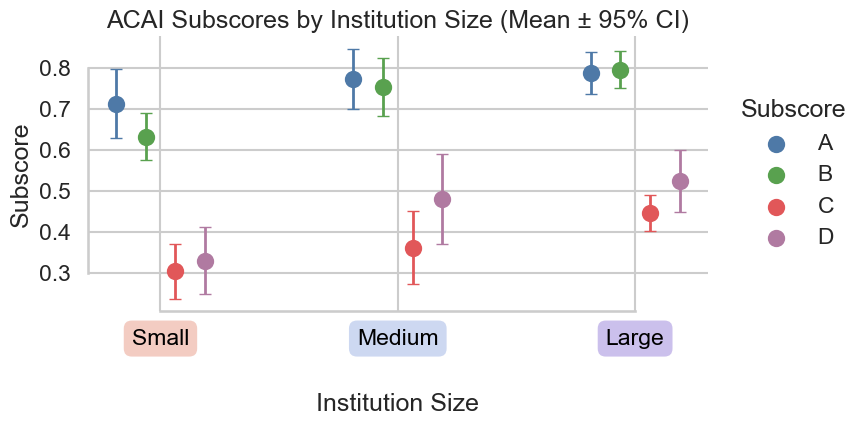

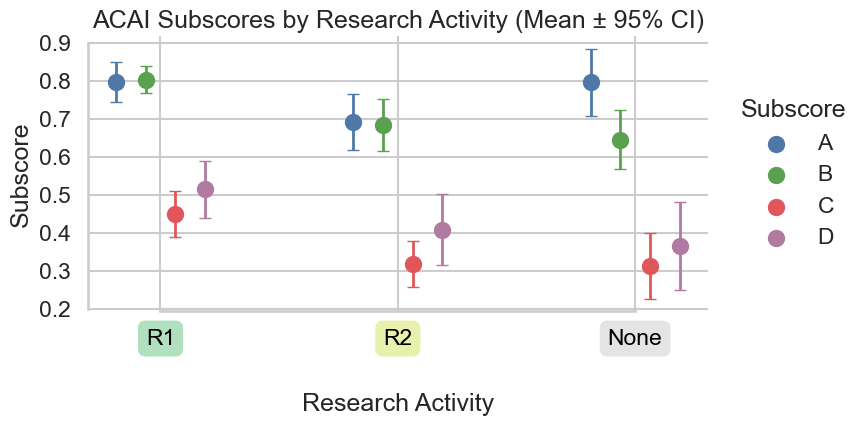

In [5]:
SUBSCORE_PALETTE = {
    "A": "#4E79A7",  # muted blue
    "B": "#59A14F",  # muted green
    "C": "#E15759",  # muted red
    "D": "#B07AA1",  # muted purple
}


SUBSCORES = {
    "A": "mean_A",
    "B": "mean_B",
    "C": "mean_C",
    "D": "mean_D",
}

plot_rows = []

for subgroup_col in subgroups.keys():
    for sub_label, sub_col in SUBSCORES.items():
        tmp = summarize_mean_ci(
            df=df,
            group_col=subgroup_col,
            value_col=sub_col
        )
        tmp["subscore"] = sub_label
        plot_rows.append(tmp)

df_plot_abcd = pd.concat(plot_rows, ignore_index=True)


def plot_subgroup_abcd(df_plot, subgroup):
    d = df_plot[df_plot["subgroup"] == subgroup].copy()

    levels = list(d["level"].unique())
    subscores = ["A", "B", "C", "D"]

    order = ORDER_MAP.get(subgroup)
    if order is not None:
        d["level"] = pd.Categorical(
            d["level"],
            categories=order,
            ordered=True
        )
        d = d.sort_values("level")


    x_base = np.arange(len(levels))

    # offsets for A/B/C/D
    dodge_width = 0.5

    
    offsets = {
        s: (i - 1.5) * (dodge_width / 4)
        for i, s in enumerate(subscores)
    }

    fig, ax = plt.subplots(figsize=(8, 5))

    # ---- Points + CIs ----
    for sub in subscores:
        sub_d = d[d["subscore"] == sub]

        x_pos = [
            x_base[levels.index(lvl)] + offsets[sub]
            for lvl in sub_d["level"]
        ]

        ax.scatter(
            x_pos,
            sub_d["mean"],
            s=120,
            color=SUBSCORE_PALETTE[sub],
            label=sub,
            zorder=3
        )

        for x, (_, row) in zip(x_pos, sub_d.iterrows()):
            ax.errorbar(
                x=x,
                y=row["mean"],
                yerr=[
                    [row["mean"] - row["ci_low"]],
                    [row["ci_high"] - row["mean"]],
                ],
                fmt="none",
                capsize=4,
                linewidth=2,
                color=SUBSCORE_PALETTE[sub],
                zorder=2
            )

    # ---- X ticks ----
    ax.set_xticks(x_base)
    raw_labels = levels
    pretty_labels = [
        LABEL_MAP.get(subgroup, {}).get(lbl, lbl)
        for lbl in raw_labels
    ]

    ax.set_xticklabels(
        pretty_labels,
        rotation=0,
        ha="center",
        multialignment="center"
    )

    # ---- Label background colors (subgroup colors) ----
    base_palette = COLOR_MAP[subgroup]

    for tick, raw_label in zip(ax.get_xticklabels(), raw_labels):
        bg = base_palette.get(raw_label, "#FFFFFF")
        tick.set_bbox(dict(
            facecolor=bg,
            edgecolor="none",
            boxstyle="round,pad=0.35",
            alpha=0.9
        ))
        tick.set_color(text_color_for_bg(bg))

    # ---- Titles & labels ----
    ax.set_title(
        f"ACAI Subscores by {SUBGROUP_DISPLAY_NAMES[subgroup]} (Mean ± 95% CI)"
    )
    ax.set_xlabel(SUBGROUP_DISPLAY_NAMES[subgroup], labelpad=32)
    ax.set_ylabel("Subscore")

    sns.despine(trim=True)
    fig.subplots_adjust(bottom=0.33)

    ax.legend(
        title="Subscore",
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5)
    )

    plt.show()



for subgroup_col in subgroups.keys():
    plot_subgroup_abcd(
        df_plot=df_plot_abcd,
        subgroup=subgroup_col
    )


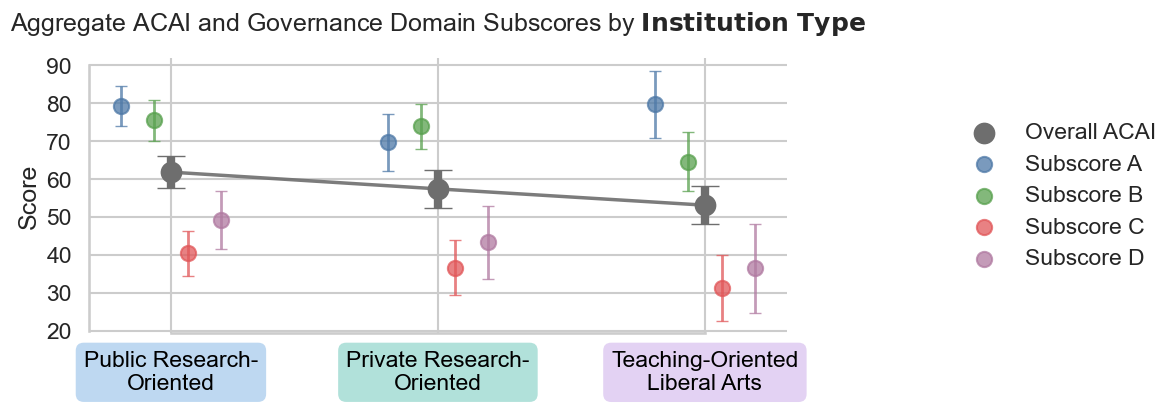

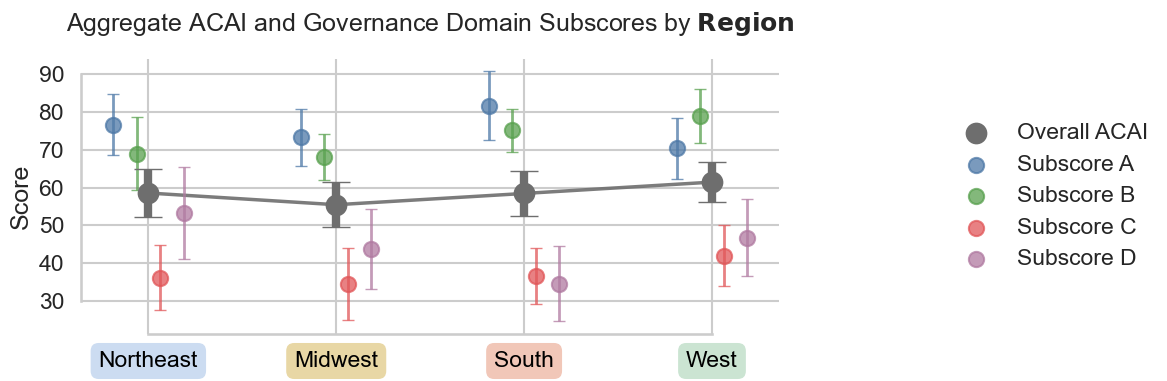

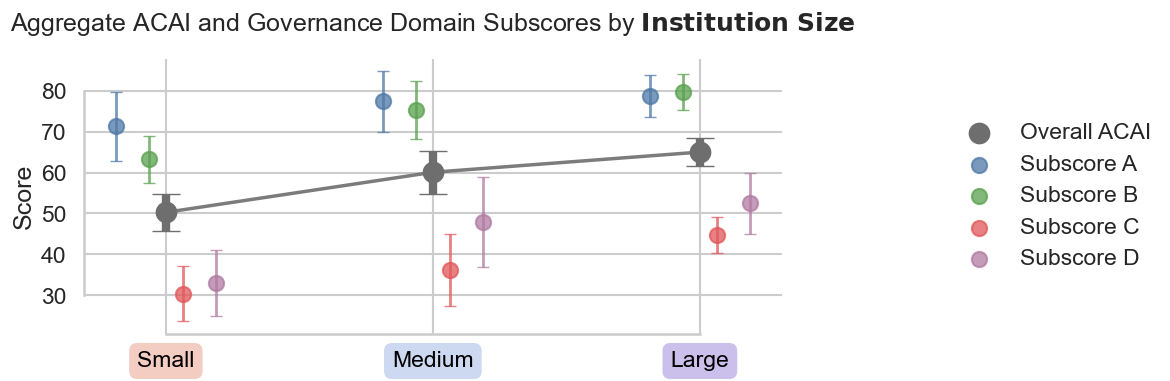

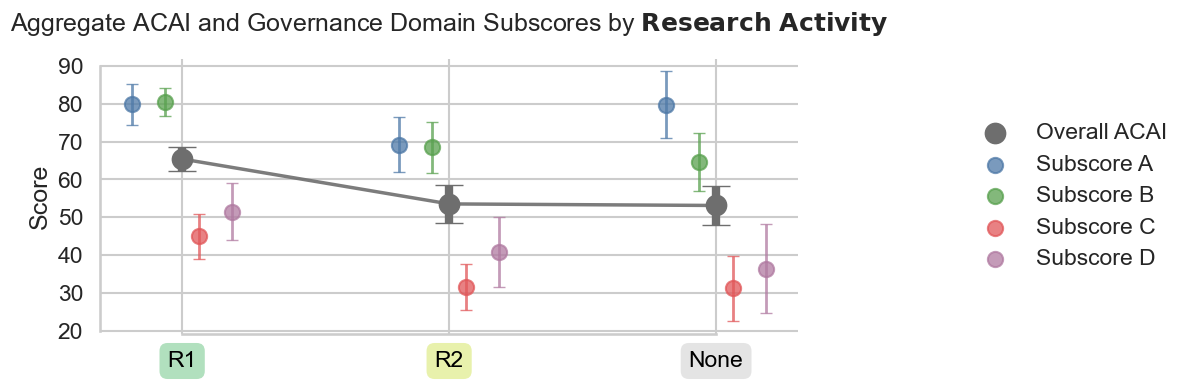

In [28]:
OVERALL_COLOR = "#6E6E6E"  # neutral medium grey

def plot_subgroup_combined(df_plot_all, df_plot_abcd, subgroup):
    # ---- subset data ----
    d_all = df_plot_all[df_plot_all["subgroup"] == subgroup].copy()
    d_sub = df_plot_abcd[df_plot_abcd["subgroup"] == subgroup].copy()

    # ---- enforce ordering ----
    order = ORDER_MAP.get(subgroup)
    if order is not None:
        d_all["level"] = pd.Categorical(d_all["level"], order, ordered=True)
        d_sub["level"] = pd.Categorical(d_sub["level"], order, ordered=True)

    d_all = d_all.sort_values("level")
    d_sub = d_sub.sort_values("level")

    levels = list(d_all["level"])
    x_base = np.arange(len(levels))

    fig, ax = plt.subplots(figsize=(9, 5))

    # ==========================================================
    # Overall ACAI (large black points)
    # ==========================================================
    ax.scatter(
        x_base,
        d_all["mean"],
        s=200,
        color=OVERALL_COLOR,
        zorder=4,
        label="Overall ACAI"
    )


    for x, (_, row) in zip(x_base, d_all.iterrows()):
        ax.errorbar(
            x=x,
            y=row["mean"],
            yerr=[
                [row["mean"] - row["ci_low"]],
                [row["ci_high"] - row["mean"]],
            ],
            fmt="none",
            capsize=10,
            linewidth=6,
            color=OVERALL_COLOR,
            zorder=3
        )
    
    # draws a line
    ax.plot(
        x_base,
        d_all["mean"],
        color=OVERALL_COLOR,
        linewidth=2.5,
        alpha=0.9,
        zorder=2
    )


    # ==========================================================
    # Subscores A/B/C/D (smaller, dodged)
    # ==========================================================
    subscores = ["A", "B", "C", "D"]
    dodge_width = 0.5

    offsets = {
        s: (i - 1.5) * (dodge_width / 4)
        for i, s in enumerate(subscores)
    }

    for sub in subscores:
        d = d_sub[d_sub["subscore"] == sub]

        x_pos = [
            x_base[levels.index(lvl)] + offsets[sub]
            for lvl in d["level"]
        ]

        ax.scatter(
            x_pos,
            d["mean"],
            s=120,
            color=SUBSCORE_PALETTE[sub],
            label=f"Subscore {sub}",
            zorder=3,
            alpha=0.75
        )

        for x, (_, row) in zip(x_pos, d.iterrows()):
            ax.errorbar(
                x=x,
                y=row["mean"],
                yerr=[
                    [row["mean"] - row["ci_low"]],
                    [row["ci_high"] - row["mean"]],
                ],
                fmt="none",
                capsize=4,
                linewidth=2,
                color=SUBSCORE_PALETTE[sub],
                zorder=2,
                alpha=0.75
            )

    # ==========================================================
    # X ticks + colored backgrounds (reuse your existing logic)
    # ==========================================================
    ax.set_xticks(x_base)

    pretty_labels = [
        LABEL_MAP.get(subgroup, {}).get(lbl, lbl)
        for lbl in levels
    ]

    ax.set_xticklabels(
        pretty_labels,
        ha="center",
        multialignment="center"
    )

    base_palette = COLOR_MAP[subgroup]
    for tick, raw_label in zip(ax.get_xticklabels(), levels):
        bg = base_palette.get(raw_label, "#FFFFFF")
        tick.set_bbox(dict(
            facecolor=bg,
            edgecolor="none",
            boxstyle="round,pad=0.35",
            alpha=0.9
        ))
        tick.set_color(text_color_for_bg(bg))

    # ==========================================================
    # Titles, labels, legend
    # ==========================================================
    ax.set_title(
        "Aggregate ACAI and Governance Domain Subscores by "
        r"$\bf{" + SUBGROUP_DISPLAY_NAMES[subgroup].replace(" ", r"\ ") + "}$",
        pad=20
    )
    # ax.set_xlabel(SUBGROUP_DISPLAY_NAMES[subgroup], labelpad=32)
    ax.set_ylabel("Score")

    ax.legend(
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.22, 0.5)
    )

    sns.despine(trim=True)
    fig.subplots_adjust(bottom=0.33)

    plt.show()


df_plot_abcd_scaled = df_plot_abcd.copy()

for col in ["mean", "ci_low", "ci_high"]:
    df_plot_abcd_scaled[col] *= 100


for subgroup_col in subgroups.keys():
    plot_subgroup_combined(
        df_plot_all=df_plot_all,
        df_plot_abcd=df_plot_abcd_scaled,
        subgroup=subgroup_col
    )

